In [ ]:
!pip install ultralytics
!pip install "deeplake<4"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 643.4/643.4 kB 22.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.3/139.3 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 70.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 132.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.3/150.3 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 8.2 MB/s eta 0:0

In [ ]:
import torch
import torch.nn as nn
from ultralytics import YOLO
import tensorflow as tf
import deeplake
import numpy
from tqdm.notebook import tqdm

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


/usr/local/lib/python3.12/dist-packages/deeplake/util/check_latest_version.py:32: UserWarning: A newer version of deeplake (4.4.0) is available. It's recommended that you update to the latest version using `pip install -U deeplake`.
  warnings.warn(


In [ ]:
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# Pre-Processing


In [ ]:
import os
import shutil
from PIL import Image
import json
import cv2
import random
from google.colab.patches import cv2_imshow
ds = deeplake.load("hub://activeloop/objectron_book_train")
ds2 = deeplake.load("hub://activeloop/objectron_book_test")

Opening dataset in read-only mode as you don't have write permissions.


\

This dataset can be visualized in Jupyter Notebook by ds.visualize() or at https://app.activeloop.ai/activeloop/objectron_book_train



-

hub://activeloop/objectron_book_train loaded successfully.



Opening dataset in read-only mode as you don't have write permissions.


\

This dataset can be visualized in Jupyter Notebook by ds.visualize() or at https://app.activeloop.ai/activeloop/objectron_book_test



-

hub://activeloop/objectron_book_test loaded successfully.



In [ ]:
output_dir = "dataset/"
os.makedirs(f"{output_dir}/images/train", exist_ok=True)
os.makedirs(f"{output_dir}/labels/train", exist_ok=True)
os.makedirs(f"{output_dir}/images/val", exist_ok=True)
os.makedirs(f"{output_dir}/labels/val", exist_ok=True)

for i, sample in enumerate(ds):
    img = sample['image'].numpy()
    keypoints = sample['point_2d'].numpy()  # first 8 corners
    keypoints = keypoints.reshape(9,3)
    keypoints = keypoints[1:,:2]
    label = 0  # 0 = book

    # save image
    decider = random.randint(0,1)
    if(img.shape == (640,480,3)):
      img_pil = Image.fromarray(img)
      img_name = f"book_{i:05d}.jpg"
      if(decider):
        img_pil.save(f"{output_dir}/images/train/{img_name}")
      else:
        img_pil.save(f"{output_dir}/images/val/{img_name}")
      keypoints_norm = keypoints.flatten().tolist()
    # save label JSON
      label_data = {"class": label, "keypoints": keypoints_norm}
      if(decider):
        with open(f"{output_dir}/labels/train/{img_name.replace('.jpg', '.json')}", 'w') as f:
          json.dump(label_data, f)
      else:
        with open(f"{output_dir}/labels/val/{img_name.replace('.jpg', '.json')}", 'w') as f:
          json.dump(label_data, f)
    if(i>5000):
      break

In [ ]:
indices = numpy.random.randint(5000,20000,1000).astype(int)
output_dir,c = "dataset/",0
os.makedirs(f"{output_dir}/images/test", exist_ok=True)
os.makedirs(f"{output_dir}/labels/test", exist_ok=True)
for i in indices:
    i = int(i)
    img = ds2.image[i].numpy()
    keypoints = ds2.point_2d[i].numpy()
    keypoints = keypoints.reshape(9,3)
    keypoints = keypoints[1:,:2]
    label = 0  # 0 = book

    if(img.shape == (640,480,3)):
      img_pil = Image.fromarray(img)
      img_name = f"book_{c:05d}.jpg"
      img_pil.save(f"{output_dir}/images/test/{img_name}")
      keypoints_flatten = keypoints.flatten().tolist()
      label_data ={"class": label, "keypoints": keypoints_flatten}
      with open(f"{output_dir}/labels/test/{img_name.replace('.jpg', '.json')}", 'w') as f:
        json.dump(label_data, f)
      c+=1

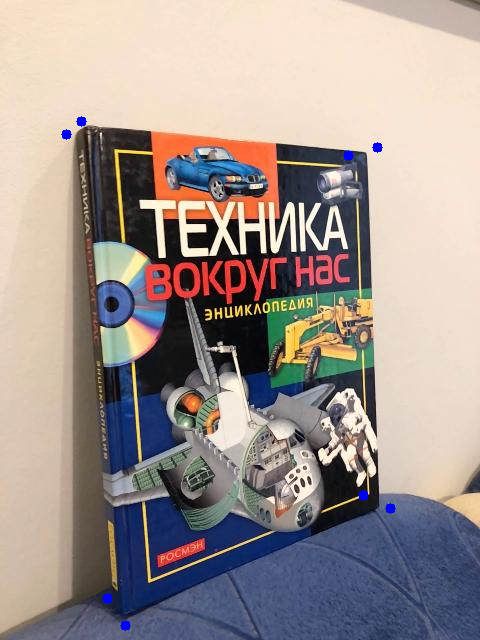

In [ ]:
# visualising a data in the dset
with open("/content/dataset/labels/test/book_00000.json", 'r', encoding='utf-8') as f:
        data = json.load(f)
        points = numpy.array(data['keypoints'])
        points = points.reshape(8,2)
img = cv2.imread("/content/dataset/images/test/book_00000.jpg")
points[:,0] = points[:,0]*img.shape[1]
points[:,1] = points[:,1]*img.shape[0]
for (x,y) in points:
  cv2.circle(img, (int(x),int(y)), 5, (255,0,0), -1)
cv2_imshow(img)

In [ ]:
#shutil.rmtree("/content/dataset")

# Model

In [ ]:
def corner_loss(y_true, y_pred):
    mse = nn.functional.mse_loss(y_pred, y_true)
    y_true_pts = y_true[:,:16].view(-1, 8, 2)
    y_pred_pts = y_pred[:,:16].view(-1, 8, 2)

    # Euclidean distance per corner
    distances = torch.sqrt(torch.sum((y_true_pts - y_pred_pts) ** 2, dim=-1))
    return mse + 0.7 * torch.mean(distances)
class CornerHead(nn.Module):
    def __init__(self, in_features, num_keypoints=8, num_classes=1):
        super().__init__()
        # Output: (num_keypoints * 2) + num_classes
        self.fc = nn.Linear(in_features, num_keypoints * 2 + num_classes)

    def forward(self, x):
        x = torch.flatten(x, 1)
        return self.fc(x)
model = YOLO('yolov8n-cls.pt')
# Extract all layers except the classification head
backbone_layers = list(model.model.model.children())[:-1]
# Wrap them into a Sequential module
backbone = nn.Sequential(*backbone_layers)
# Determine output feature size dynamically
dummy = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    features = model.model.model[:-1](dummy)
in_features = features.shape[1]
new_head = CornerHead(in_features=in_features)
custom_model = nn.Sequential(backbone, new_head)

In [ ]:
class CornerDataset(Dataset):
    def __init__(self, img_dir, label_dir, transform=None):
        self.img_dir = img_dir
        self.label_dir = label_dir
        self.transform = transform
        self.img_files = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_name = self.img_files[idx]
        img_path = os.path.join(self.img_dir, img_name)
        label_path = os.path.join(self.label_dir, img_name.replace('.jpg', '.json'))

        img = Image.open(img_path).convert("RGB")
        with open(label_path, 'r') as f:
            label_data = json.load(f)

        label = torch.tensor([label_data["class"]], dtype=torch.float32)
        keypoints = torch.tensor(label_data["keypoints"], dtype=torch.float32)

        if self.transform:
            img = self.transform(img)

        target = torch.cat((keypoints, label))  # [x1..y8, class]
        return img, target

In [ ]:
transform = T.Compose([
    T.Resize((640, 480)),
    T.ToTensor(),
])

train_dataset = CornerDataset(
    img_dir='dataset/images/train',
    label_dir='dataset/labels/train',
    transform=transform
)
val_dataset = CornerDataset(
    img_dir='dataset/images/val',
    label_dir='dataset/labels/val',
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
custom_model = custom_model.to(device)
optimizer = torch.optim.Adam(custom_model.parameters(), lr=1e-4, weight_decay=1e-5)

In [ ]:
dummy = torch.randn(1, 3, 640, 480).to(device)
with torch.no_grad():
    features = model.model.model[:-1](dummy)   # all but last classification layer
    flat_dim = features.view(features.size(0), -1).shape[1]
print("Detected feature size:", flat_dim)

new_head = CornerHead(in_features=flat_dim).to(device)

custom_model = nn.Sequential(
    model.model.model[:-1],   # the backbone layers
    nn.Flatten(),
    new_head
).to(device)

Detected feature size: 76800


In [ ]:
train_losses, val_losses = [], []
num_epochs=13
for epoch in range(num_epochs):
    custom_model.train()
    running_loss = 0.0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
    for imgs, targets in progress_bar:
        imgs, targets = imgs.to(device), targets.to(device)

        preds = custom_model(imgs)
        loss = corner_loss(targets, preds)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        progress_bar.set_postfix({"loss": f"{loss.item():.4f}"})

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    # Validation at the end of each epoch
    custom_model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs, targets = imgs.to(device), targets.to(device)
            preds = custom_model(imgs)
            loss = corner_loss(targets, preds)
            val_loss += loss.item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss {train_loss:.4f} | Val Loss {val_loss:.4f}")

    # ✅ save best model automatically
    if val_loss <= min(val_losses):
        #torch.save(custom_model.state_dict(), save_path)
        print("📦best model checkpoint!")

Epoch 1/13:   0%|          | 0/307 [00:00<?, ?it/s]

Epoch [1/13] | Train Loss 1.0184 | Val Loss 1.0222
📦best model checkpoint!


Epoch 2/13:   0%|          | 0/307 [00:00<?, ?it/s]

Epoch [2/13] | Train Loss 1.0152 | Val Loss 1.0146
📦best model checkpoint!


Epoch 3/13:   0%|          | 0/307 [00:00<?, ?it/s]

...

Epoch [11/13] | Train Loss 1.0155 | Val Loss 1.0273


Epoch 12/13:   0%|          | 0/307 [00:00<?, ?it/s]

Epoch [12/13] | Train Loss 1.0186 | Val Loss 1.0272


Epoch 13/13:   0%|          | 0/307 [00:00<?, ?it/s]

Epoch [13/13] | Train Loss 1.0172 | Val Loss 1.0099
📦best model checkpoint!


In [ ]:
for epoch in range(500):
    optimizer.zero_grad()
    preds = custom_model(imgs)
    loss = corner_loss(targets, preds)
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        print(epoch, loss.item())

0 0.9478334188461304
50 0.9478334188461304
100 0.9478334188461304
150 0.9478334188461304
200 0.9478334188461304
250 0.9478334188461304
300 0.9478334188461304
350 0.9478334188461304
400 0.9478334188461304
450 0.9478334188461304
